##Plot detector efficiencies from combined_detector_efficiencies.csv



In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
plt.rcParams['font.family']='monospace'
plt.rcParams['font.size']=12
plt.rc('text',usetex=True)
data=np.genfromtxt('/home/amak/SolarAxionFlux/combined_detector_efficiencies.csv', delimiter=',')


In [3]:
# Extract columns: Energy [keV] is column 6, 30mm Ar Abs. is column 2, LLNL is column 7
en = data[:, 6]
ar = data[:, 2]
llnl = data[:, 7]
#ful=data[:,13]
sin=data[:,0]
al=data[:,3]
mask = (en >= 0) & (en <= 10)
energy = en[mask]
ar_abs = ar[mask]
llnl = llnl[mask]
#full = ful[mask]
sin = sin[mask]
al = al[mask]

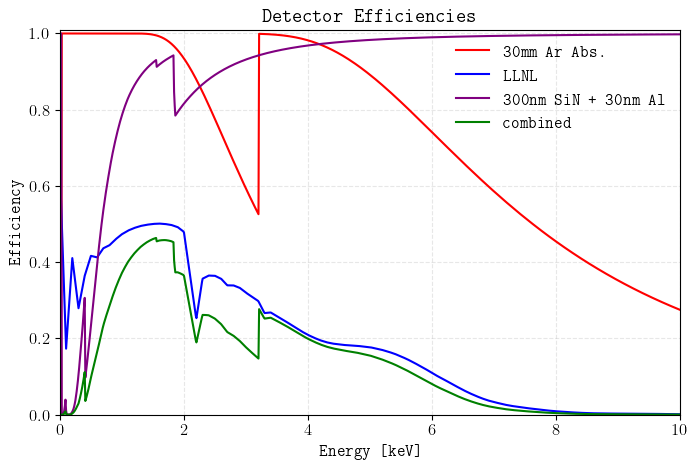

In [4]:
fig, ax=plt.subplots(figsize=(8, 5))
# Plot both detector efficiencies
ax.plot(energy, ar_abs, '-',color='red', label=r'30mm Ar Abs.')
ax.plot(energy, llnl, '-', color='blue', label=r'LLNL')
ax.plot(energy, sin * al, '-', color='purple', label=r'300nm SiN + 30nm Al')
ax.plot(energy, ar_abs*llnl*sin*al, '-', color='green', label=r'combined')
#ax.plot(energy, al, '-', color='purple', label=r'30nm Al')
# Set labels and title
ax.set_xlabel(r'Energy [keV]')
ax.set_ylabel(r'Efficiency')
ax.set_title(r'Detector Efficiencies')


# Set axis limits
ax.set_xlim([0, 10])
ax.set_ylim([0, 1.01])
# Add legend
ax.legend(frameon=False, loc='best')

# Add grid (optional)
ax.grid(True, alpha=0.3, linestyle='--')


ValueError: operands could not be broadcast together with shapes (1001,) (1000,) 

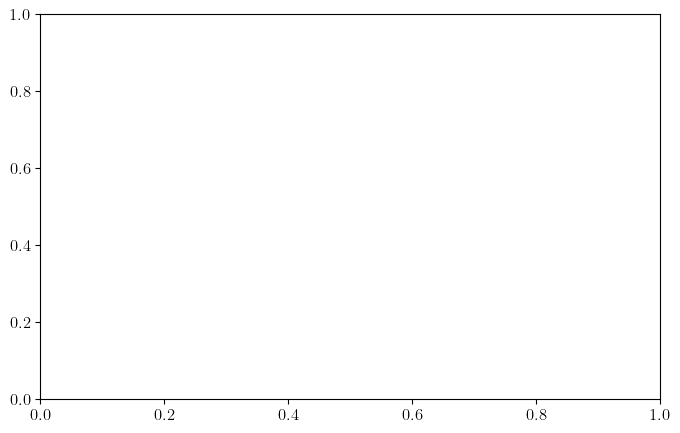

In [5]:
fig, ax=plt.subplots(figsize=(8, 5))
# Use full energy data (not masked) for the log-scale plot
combined_eff = en * ar * llnl * sin * al
ax.plot(en, combined_eff, '-', color='green', label=r'combined')
ax.set_xlabel(r'Energy [keV]')
ax.set_ylabel(r'Efficiency')
ax.set_title(r'Detector Efficiencies')
# Set axis limits
ax.set_xlim([1.0e-3, 10])
ax.set_ylim([1.0e-8, 1.0])
ax.set_yscale('log')
ax.set_xscale('log')
# Add legend
ax.legend(frameon=False, loc='best')

# Add grid (optional)
ax.grid(True, alpha=0.3, linestyle='--')
plt.show()

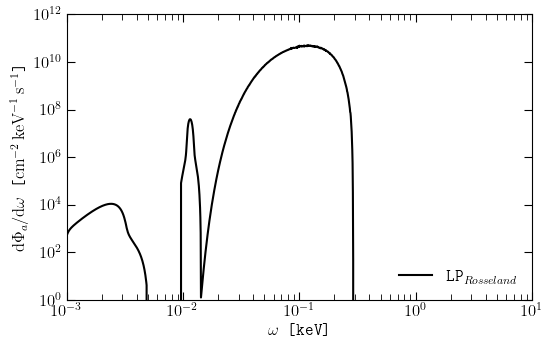

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Courier New']
plt.rcParams['font.size']= 12
 #settings
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}')

LP_flux = np.genfromtxt("/home/amak/SolarAxionFlux/results/LP_Rosseland.dat")
fig, ax = plt.subplots()
def plot_setup(size=6,ratio=0.618):
    fig.set_size_inches(size,ratio*size)
    ax.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=4)
plot_setup()
ax.plot(LP_flux[:,0], ((LP_flux[:,1])/1.0), 'k-', label=r'LP$_{Rosseland}$ ') #this is the Rosseland one based on Rosseland, but we want to show the magnetic field uncertainty band


ax.set_xlabel(r'$\omega$ [keV]')
ax.set_ylabel(r'$\mathrm{d}\Phi_a/\mathrm{d}\omega$ [\SI{}{\per\cm\squared\per\keV\per\s}]')
ax.set_xlim([1.0e-3,10])
ax.set_ylim([1.0e0, 1.0e12])
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(frameon=False, loc='lower right')
plt.show()


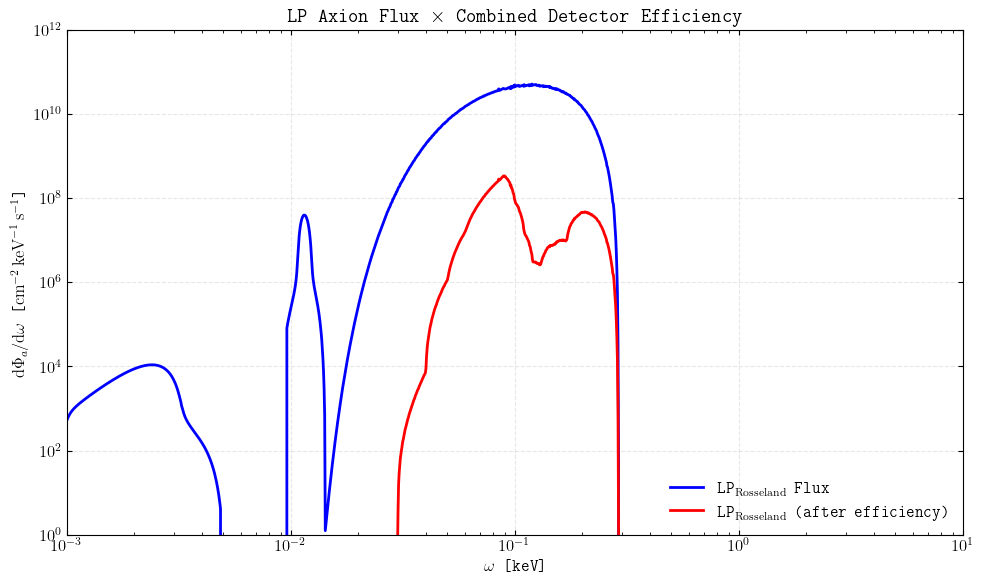

In [7]:
# Use full energy data (not the 0-10 keV masked version)
en_full = data[:, 6]  # Full energy array (1000 points)
ar_full = data[:, 2]
llnl_full = data[:, 7]
sin_full = data[:, 0]
al_full = data[:, 3]

# Combined efficiency on full grid
combined_eff_full = ar_full * llnl_full * sin_full * al_full

# Interpolate to LP flux energy grid
from scipy.interpolate import interp1d

eff_interp = interp1d(en_full, combined_eff_full, kind='linear', fill_value='extrapolate')

# Get efficiency at LP flux energies
lp_energy = LP_flux[:, 0]
lp_flux_values = LP_flux[:, 1]
eff_at_lp_energy = eff_interp(lp_energy)

# Calculate detected flux
detected_flux = eff_at_lp_energy * lp_flux_values

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(lp_energy, lp_flux_values, 'b-', linewidth=2, label=r'LP$_{\mathrm{Rosseland}}$ Flux')
ax.plot(lp_energy, detected_flux, 'r-', linewidth=2, label=r'LP$_{\mathrm{Rosseland}}$ (after efficiency)')
#ax.loglog(lp_energy, eff_at_lp_energy, 'g--', linewidth=1.5, alpha=0.7, label=r'Combined efficiency')

ax.set_xlabel(r'$\omega$ [keV]')
ax.set_ylabel(r'$\mathrm{d}\Phi_a/\mathrm{d}\omega$ [\SI{}{\per\cm\squared\per\keV\per\s}]')
ax.set_title(r'LP Axion Flux $\times$ Combined Detector Efficiency')
ax.set_xlim([1e-3, 10])
ax.set_ylim([1e0, 1e12])
ax.set_yscale('log')
ax.set_xscale('log')

ax.legend(frameon=False, loc='lower right')

ax.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

plt.tight_layout()

ax.grid(True, alpha=0.3, linestyle='--')
plt.savefig('detected_flux_lp_combined_eff.png', dpi=300)
plt.show()

## Plot Background Rate from background_rate_mlp.csv (MLP@95)

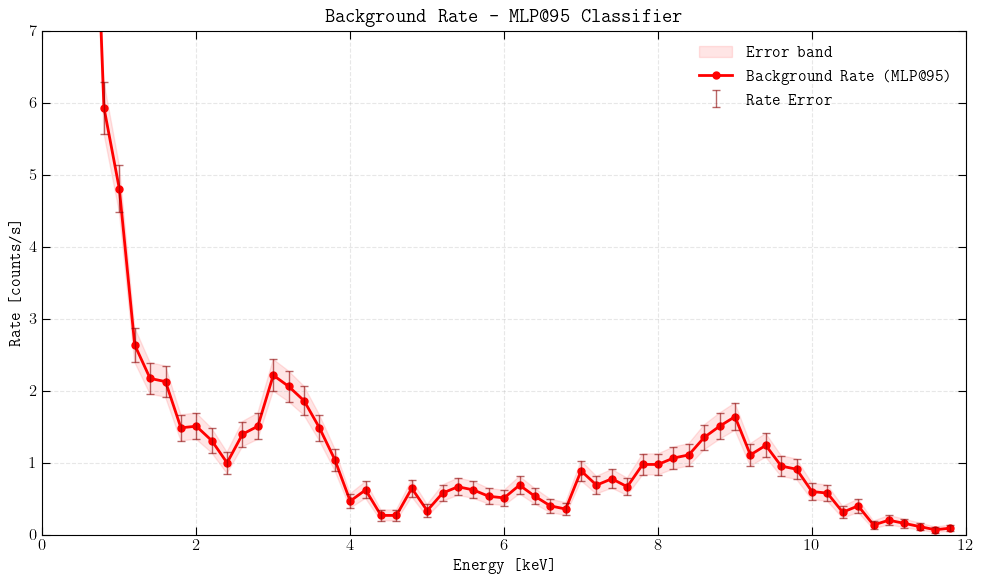

In [8]:
import pandas as pd

# Load background rate data
bg_data = pd.read_csv('/home/amak/SolarAxionFlux/background_rate_mlp.csv')

# Filter for MLP@95 dataset
mlp95_data = bg_data[bg_data['Dataset'] == 'MLP@95'].reset_index(drop=True)

# Extract columns
energy_bg = mlp95_data['Energy'].values
rate_bg = mlp95_data['Rate'].values
rate_err = mlp95_data['RateErr'].values
y_min = mlp95_data['yMin'].values  # Lower error bound
y_max = mlp95_data['yMax'].values  # Upper error bound

# Create figure for background rate
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Plot shaded error background using fill_between
ax2.fill_between(energy_bg, y_min, y_max, alpha=0.1, color='red', label=r'Error band')

# Plot main rate line
ax2.plot(energy_bg, rate_bg, '-o', color='red', linewidth=2, markersize=5, label=r'Background Rate (MLP@95)')

# Add error bars on top
ax2.errorbar(energy_bg, rate_bg, yerr=rate_err, fmt='none', ecolor='darkred', 
             elinewidth=1, capsize=3, capthick=1, alpha=0.6, label=r'Rate Error')

# Set labels and title
ax2.set_xlabel(r'Energy [keV]')
ax2.set_ylabel(r'Rate [counts/s]')
ax2.set_title(r'Background Rate - MLP@95 Classifier')

# Set axis limits
ax2.set_xlim([0, 12])
ax2.set_ylim([0,7])

# Add legend
ax2.legend(frameon=False, loc='best')

# Add grid
ax2.grid(True, alpha=0.3, linestyle='--')

# Apply professional styling
ax2.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)
ax2.tick_params(which='major', length=6)
ax2.tick_params(which='minor', length=4)

plt.tight_layout()
plt.savefig('/home/amak/SolarAxionFlux/background_rate_mlp95.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
energy_min, energy_max = 0.2, 8
mask_energy = (energy_bg >= energy_min) & (energy_bg <= energy_max)
avg_rate_range = np.mean(rate_bg[mask_energy])
print(f"Average background rate ({energy_min}-{energy_max} keV): {avg_rate_range:.4f} counts/s")



Average background rate (0.2-8 keV): 3.4665 counts/s


Average rate (0.2–8 keV): 5.648 ± 0.056 [10^-5 keV^-1 cm^-2 s^-1]


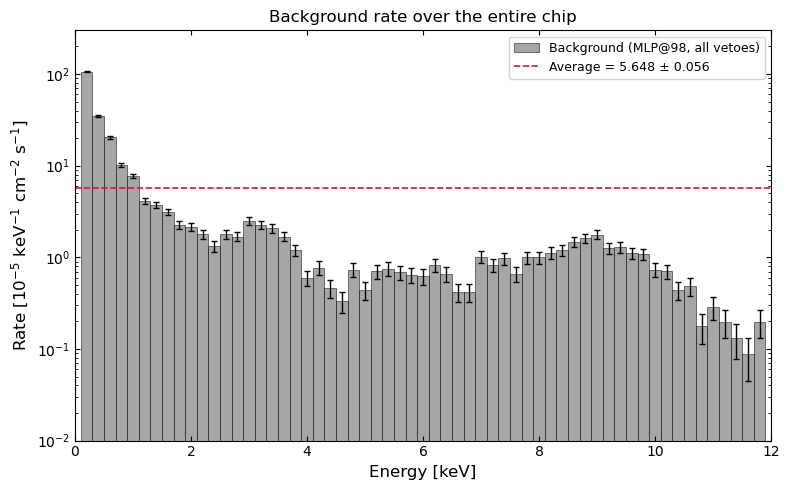

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 1. Load the CSV
# ------------------------------------------------------------------
csv_path = '/home/amak/SolarAxionFlux/background_rate_mlp.csv'
df = pd.read_csv(csv_path)

# ------------------------------------------------------------------
# 2. Select the same conditions as the paper (Figure 6)
#    - Classifier: MLP
#    - Software efficiency: 98 %  (Dataset == "MLP@98")
#    - All vetoes enabled
# ------------------------------------------------------------------
mask = (
    (df['Dataset'] == 'MLP@98') &
    (df['Classifier'] == 'MLP') &
    (df['Scinti'] == True) &
    (df['FADC'] == True) &
    (df['Septem'] == True) &
    (df['Line'] == True)
)
df_sel = df[mask].sort_values('Energy').reset_index(drop=True)

# ------------------------------------------------------------------
# 3. Extract physics quantities
#    Energy     : keV  (bin centres, 0.2 keV spacing)
#    Rate       : 10^-5 keV^-1 cm^-2 s^-1  (already in paper units)
#    RateErr    : 1-sigma statistical uncertainty (same units)
# ------------------------------------------------------------------
energy    = df_sel['Energy'].values          # keV
rate      = df_sel['Rate'].values              # 10^-5 keV^-1 cm^-2 s^-1
rate_err  = df_sel['RateErr'].values           # same units

# Build histogram bin edges from the 0.2 keV bin centres
bin_width = 0.2
bin_edges = np.arange(energy.min() - bin_width/2,
                      energy.max() + bin_width/2 + 1e-6,
                      bin_width)

# ------------------------------------------------------------------
# 4. Compute the average rate over 0.2 – 8.0 keV
#    (the paper quotes 1.056(69) x 10^-5 keV^-1 cm^-2 s^-1)
# ------------------------------------------------------------------
mask_avg = (energy >= 0.2) & (energy <= 8.0)
avg_rate = np.mean(rate[mask_avg])
# Rough combined error: sqrt(sum(err^2)) / N_bins
avg_err  = np.sqrt(np.sum(rate_err[mask_avg]**2)) / mask_avg.sum()

print(f"Average rate (0.2–8 keV): {avg_rate:.3f} ± {avg_err:.3f} "
      f"[10^-5 keV^-1 cm^-2 s^-1]")

# ------------------------------------------------------------------
# 5. Plot in the same style as the paper (Figure 6)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Gray histogram bars (step/filled style matching the paper)
ax.hist(energy, bins=bin_edges, weights=rate,
        color='gray', alpha=0.7, edgecolor='black', linewidth=0.5,
        label='Background (MLP@98, all vetoes)')

# Black error bars at bin centres
ax.errorbar(energy, rate, yerr=rate_err,
            fmt='none', ecolor='black', capsize=2, capthick=1, linewidth=1)

# Horizontal line showing the 0.2–8 keV average
ax.axhline(avg_rate, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Average = {avg_rate:.3f} ± {avg_err:.3f}')

# ------------------------------------------------------------------
# 6. Labels, units, and limits (matching the paper)
# ------------------------------------------------------------------
ax.set_xlabel('Energy [keV]', fontsize=12)
ax.set_ylabel('Rate [$10^{-5}$ keV$^{-1}$ cm$^{-2}$ s$^{-1}$]', fontsize=12)
ax.set_title(r'Background rate over the entire chip', fontsize=12)


# Give a little headroom above the highest peak
ax.set_ylim(0.01, 300)
ax.set_xlim([0, 12])
ax.set_yscale('log')
#ax.set_xscale('log')
# Inward ticks (typical for physics plots)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig('cast_gridpix_background_mlp98.png', dpi=300)
plt.show()